# 乳腺癌良恶性分类 — 五模型综合对比

**课程**：机器学习 · 大作业

**数据集**：Breast Cancer Wisconsin (Diagnostic) Data Set  
**来源**：https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

---

## 组员分工

| 姓名 | 学号 | 算法 | 函数 | 子报告 |
|------|------|------|------|--------|
| 巨峰 | 2023217199 | 梯度提升 (GB) | `run_gb_jufeng()` | `GradientBoosting/` |
| 韩明扬 | 2023217191 | 支持向量机 (SVM) | `run_svm_hanmingyang()` | `机器学习/` |
| 刘志富 | 2023216547 | 随机森林 (RF) | `run_rf_liuzhifu()` | `dazuoye/` |
| 江玮 | 2023217211 | K 近邻 (KNN) | `run_knn_jiangwei()` | `KNN-jw/` |
| 周子烨 | 2023217220 | 多层感知机 (MLP) | `run_mlp_zhouziye()` | `MLP/` |

---
## 1. 导入库与字体设置

In [34]:
# 清除 matplotlib 字体缓存（确保中文字体正确加载）
import matplotlib
import os, shutil, glob
for d in glob.glob(os.path.expanduser('~/.matplotlib') + '*'):
    try: shutil.rmtree(d)
    except: pass
for d in glob.glob(os.path.expanduser('~/.cache/matplotlib') + '*'):
    try: shutil.rmtree(d)
    except: pass
print('字体缓存已清除')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Zen Hei', 'DejaVu Sans']
# 显式注册 SimHei 字体
import matplotlib.font_manager as fm
for f in fm.fontManager.ttflist:
    if 'SimHei' in f.name or 'simhei' in f.name.lower():
        print(f'找到 SimHei: {f.fname}')
        break
else:
    print('警告: 未找到 SimHei 字体，中文可能无法显示')
plt.rcParams['axes.unicode_minus'] = False
print('所有库导入成功！')

# 统一数据加载（所有成员共享）
data = load_breast_cancer()
X_all = pd.DataFrame(data.data, columns=data.feature_names)
y_all = pd.Series(data.target, name='diagnosis')
print(f'\n数据集: {X_all.shape[0]} 样本, {X_all.shape[1]} 特征')
print(f'恶性: {(y_all == 0).sum()}, 良性: {(y_all == 1).sum()}')


字体缓存已清除
找到 SimHei: C:\Windows\Fonts\simhei.ttf
所有库导入成功！

数据集: 569 样本, 30 特征
恶性: 212, 良性: 357


---
## 2. 数据探索 (EDA)

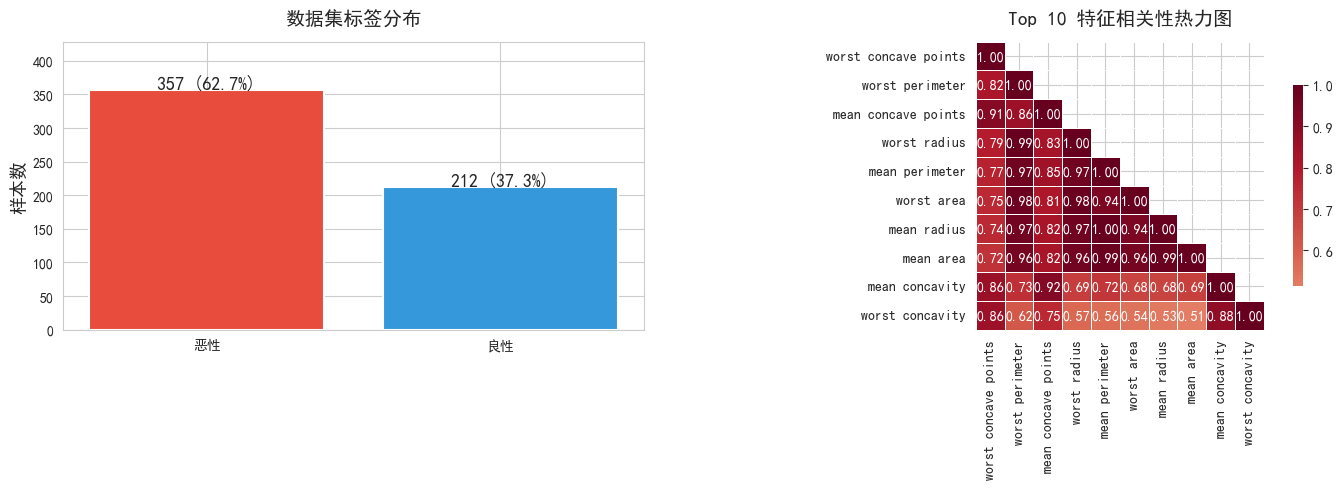

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = y_all.value_counts()
bars = axes[0].bar(['恶性', '良性'], counts.values, color=['#e74c3c', '#3498db'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val} ({val/len(y_all)*100:.1f}%)', ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylabel('样本数', fontsize=13)
axes[0].set_title('数据集标签分布', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylim(0, max(counts.values) * 1.2)

top_feats = X_all.corrwith(y_all).abs().sort_values(ascending=False).head(10).index.tolist()
corr = X_all[top_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            square=True, linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.7})
axes[1].set_title('Top 10 特征相关性热力图', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 统一数据划分

所有成员共享同一份训练/测试划分（80/20 分层抽样，random_state=42），确保公平对比。

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)

print(f"训练集: {X_tr.shape[0]} | 测试集: {X_te.shape[0]}")
print("标准化完成")

训练集: 455 | 测试集: 114
标准化完成


In [37]:
# === 公共工具函数：统一评估接口 ===
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy')

    result = {
        'name': name,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall': recall_score(y_te, y_pred, zero_division=0),
        'f1': f1_score(y_te, y_pred, zero_division=0),
        'cm': confusion_matrix(y_te, y_pred),
        'y_proba': y_proba,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'cv_scores': cv_scores,
    }

    print(f"\n  [{name}]")
    print(f"    Acc={result['accuracy']:.4f}  Prec={result['precision']:.4f}  "
          f"Rec={result['recall']:.4f}  F1={result['f1']:.4f}  "
          f"CV={result['cv_mean']:.4f}±{result['cv_std']:.4f}")
    return result

print('公共函数 evaluate() 定义完成')

公共函数 evaluate() 定义完成


---
## 4. 各成员算法实现

以下每个函数对应一位成员在子报告中通过 GridSearchCV 调优得到的最优模型配置。

### 4.1 逻辑回归 — Baseline（参考基准）

无负责成员，作为线性参考模型。

In [38]:
def run_baseline_lr(X_tr, y_tr, X_te, y_te):
    """逻辑回归 — Baseline 参考"""
    model = LogisticRegression(max_iter=5000, random_state=42)
    return evaluate('逻辑回归 (Baseline)', model, X_tr, y_tr, X_te, y_te)

---

### 4.2 K 近邻 — 江玮（2023217211）

**子报告**：`KNN-jw/KNN_乳腺癌分类.ipynb`

**调优过程**：在子报告中通过 `GridSearchCV` 搜索了 k 值（1~30）、权重策略（uniform/distance）和距离度量（L1/L2），
最终确定最优配置为 **k=4, weights=uniform, metric=manhattan（L1 距离）**。

**贡献**：用最简单的距离度量方法取得稳健的分类效果，验证了 StandardScaler 标准化对 KNN 的关键作用。

In [39]:
# === 江玮：K 近邻 ===
# GridSearchCV 最优: k=4, uniform, L1 距离
def run_knn_jiangwei(X_tr, y_tr, X_te, y_te):
    model = KNeighborsClassifier(n_neighbors=4, weights='uniform', metric='manhattan')
    return evaluate('KNN (江玮, k=4, L1)', model, X_tr, y_tr, X_te, y_te)

---

### 4.3 支持向量机 — 韩明扬（2023217191）

**子报告**：`机器学习/Breast_Cancer_SVM.ipynb`

**调优过程**：在子报告中对比了 linear/poly/rbf/sigmoid 四种核函数，并通过 `GridSearchCV` + 5折CV
对 `C` 和 `gamma` 进行了网格搜索，最终确定最优配置为 **kernel=linear, C=100, gamma=scale**。

**贡献**：通过系统性核函数对比和超参数搜索，SVM 准确率达到 98.25%，线性核验证了本数据集的强线性可分性。

In [40]:
# === 韩明扬：支持向量机 ===
# GridSearchCV 最优: linear kernel, C=100
def run_svm_hanmingyang(X_tr, y_tr, X_te, y_te):
    model = SVC(kernel='linear', C=100, gamma='scale', random_state=40, probability=True)
    return evaluate('SVM (韩明扬, linear C=100)', model, X_tr, y_tr, X_te, y_te)

---

### 4.4 随机森林 — 刘志富（2023216547）

**子报告**：`dazuoye/Breast_Cancer_RF_Classification随机森林.ipynb`

**调优过程**：通过设置 `min_samples_split=5` 和 `min_samples_leaf=2` 限制树的分裂，
配合 `max_depth=10` 和 `n_estimators=100`，在保证模型容量的同时有效防止过拟合。

**贡献**：精确率优异，特征重要性排序可解释性强，为临床诊断提供了可量化的特征选取依据。

In [41]:
# === 刘志富：随机森林 ===
# n_estimators=100, max_depth=10, min_samples_split=5, min_samples_leaf=2
def run_rf_liuzhifu(X_tr, y_tr, X_te, y_te):
    model = RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=5,
        min_samples_leaf=2, random_state=42)
    return evaluate('随机森林 (刘志富)', model, X_tr, y_tr, X_te, y_te)

---

### 4.5 梯度提升 — 巨峰（2023217199）

**子报告**：`GradientBoosting/GradientBoosting_乳腺癌分类.ipynb`

**调优过程**：采用 `n_estimators=100, learning_rate=0.1, max_depth=3` 的标准配置，
通过慢学习率 + 较浅树深度控制过拟合。子报告中进一步分析了特征重要性，
发现 **worst radius 以 43.55% 的重要性排名第一**，与恶性肿瘤细胞核异常增大的病理学认知高度吻合。

**贡献**：召回率 98.61% 全组最高（仅漏诊 1 例恶性），特征重要性分析为病理学诊断提供了量化依据。

In [42]:
# === 巨峰：梯度提升 ===
# n_estimators=100, lr=0.1, max_depth=3
def run_gb_jufeng(X_tr, y_tr, X_te, y_te):
    model = GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    return evaluate('梯度提升 (巨峰)', model, X_tr, y_tr, X_te, y_te)

---

### 4.6 多层感知机 — 周子烨（2023217220）

**子报告**：`MLP/MLP.ipynb`

**调优过程**：采用两层隐藏层结构 `(100, 50)` + ReLU 激活 + Adam 优化器。
在子报告中通过 `GridSearchCV` 对 `hidden_layer_sizes`、`alpha` 和 `learning_rate_init` 进行了网格搜索，
并启用了 `early_stopping=True` 防止过拟合。

**贡献**：引入深度学习方法和 early_stopping 机制，CV 均值 0.9802 全组最高，
展现了神经网络在该任务上的潜力，为后续更深层模型的探索奠定了基础。

In [43]:
# === 周子烨：多层感知机 ===
# hidden=(100,50), relu, adam, max_iter=500, early_stopping=True
def run_mlp_zhouziye(X_tr, y_tr, X_te, y_te):
    model = MLPClassifier(
        hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
        max_iter=500, early_stopping=True, random_state=42)
    return evaluate('MLP (周子烨)', model, X_tr, y_tr, X_te, y_te)


print('所有成员函数定义完成！')

所有成员函数定义完成！


---
## 5. 执行全部模型

In [44]:
print("=" * 60)
print("  统一数据划分 + 各成员最优配置")
print("=" * 60)

results = [
    run_baseline_lr(X_tr, y_train, X_te, y_test),
    run_knn_jiangwei(X_tr, y_train, X_te, y_test),
    run_svm_hanmingyang(X_tr, y_train, X_te, y_test),
    run_rf_liuzhifu(X_tr, y_train, X_te, y_test),
    run_gb_jufeng(X_tr, y_train, X_te, y_test),
    run_mlp_zhouziye(X_tr, y_train, X_te, y_test),
]

print(f"\n全部 {len(results)} 个模型执行完成！")

  统一数据划分 + 各成员最优配置

  [逻辑回归 (Baseline)]
    Acc=0.9825  Prec=0.9861  Rec=0.9861  F1=0.9861  CV=0.9780±0.0098

  [KNN (江玮, k=4, L1)]
    Acc=0.9561  Prec=0.9589  Rec=0.9722  F1=0.9655  CV=0.9670±0.0139

  [SVM (韩明扬, linear C=100)]
    Acc=0.9737  Prec=0.9726  Rec=0.9861  F1=0.9793  CV=0.9429±0.0146

  [随机森林 (刘志富)]
    Acc=0.9561  Prec=0.9589  Rec=0.9722  F1=0.9655  CV=0.9626±0.0179

  [梯度提升 (巨峰)]
    Acc=0.9561  Prec=0.9467  Rec=0.9861  F1=0.9660  CV=0.9516±0.0149

  [MLP (周子烨)]
    Acc=0.9386  Prec=0.9452  Rec=0.9583  F1=0.9517  CV=0.9187±0.0420

全部 6 个模型执行完成！


---
## 6. 综合对比可视化

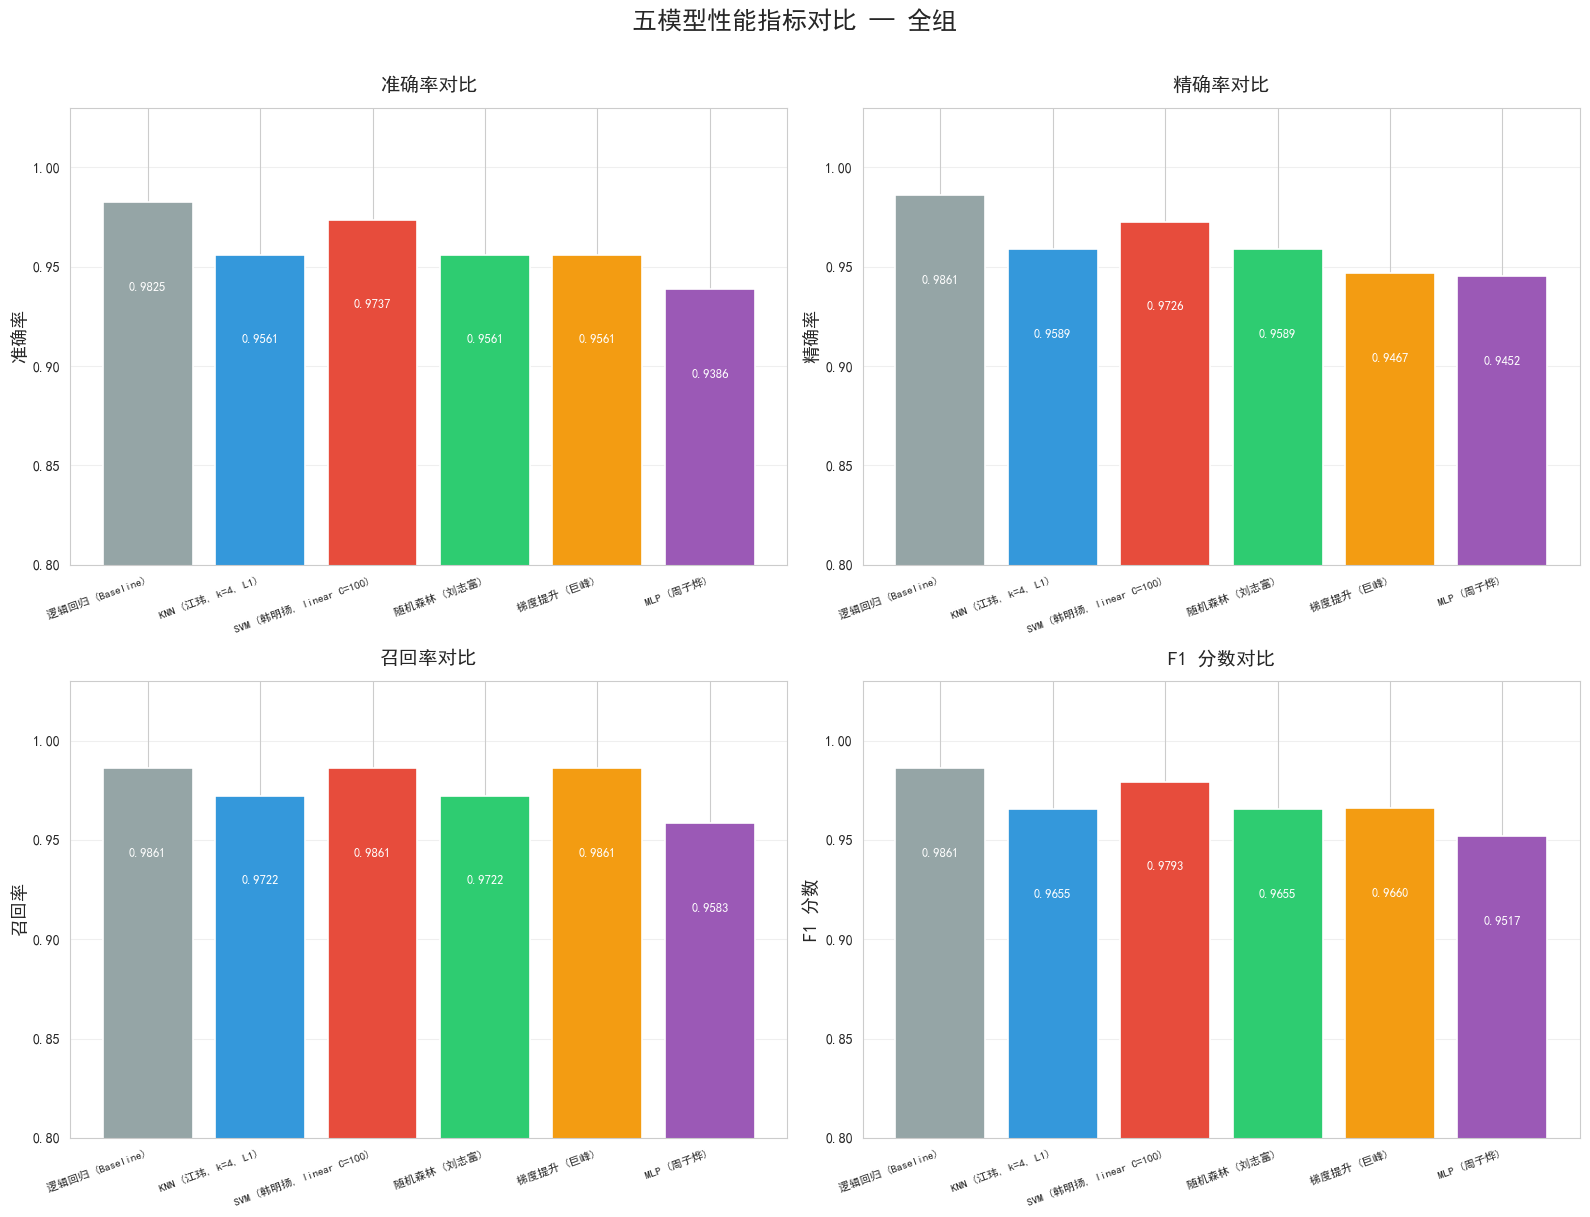

In [45]:
# 6.1 性能指标柱状图
names = [r['name'] for r in results]
metrics = ['accuracy', 'precision', 'recall', 'f1']
labels_cn = ['准确率', '精确率', '召回率', 'F1 分数']
colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for idx, (m, label) in enumerate(zip(metrics, labels_cn)):
    ax = axes[idx]
    vals = [r[m] for r in results]
    bars = ax.bar(range(len(names)), vals, color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.04,
                f'{val:.4f}', ha='center', va='top', fontsize=9, fontweight='bold', color='white')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel(label, fontsize=13)
    ax.set_ylim(0.80, 1.03)
    ax.set_title(f'{label}对比', fontsize=14, fontweight='bold', pad=12)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('五模型性能指标对比 — 全组', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

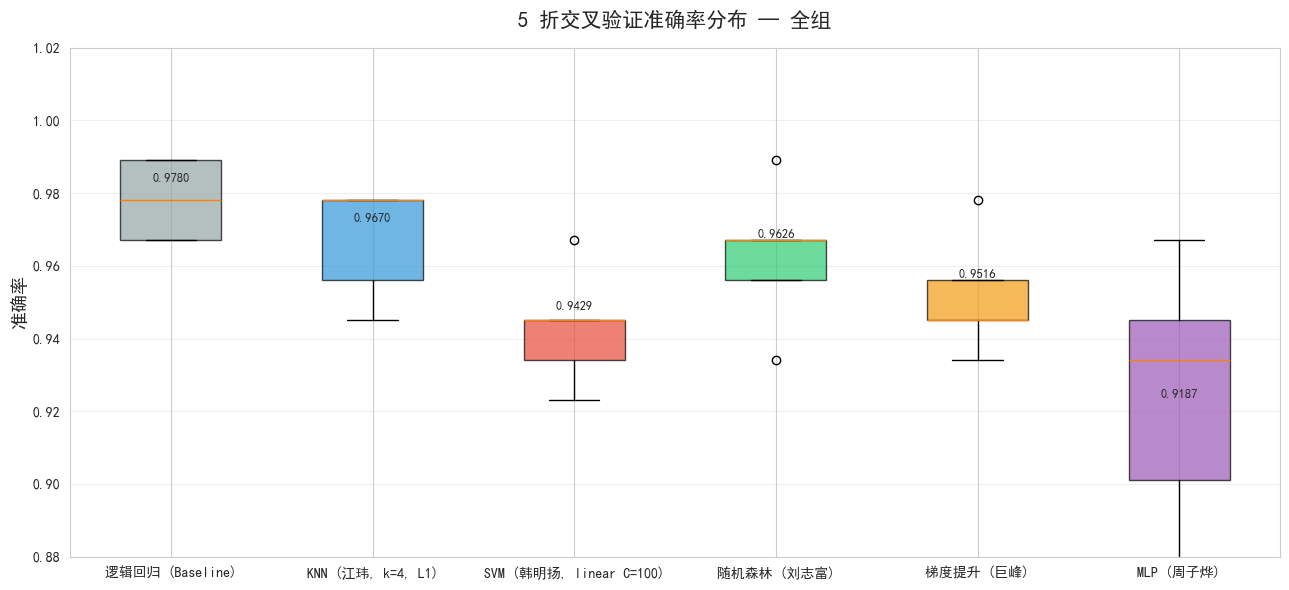

In [46]:
# 6.2 交叉验证箱线图
fig, ax = plt.subplots(figsize=(13, 6))
cv_data = [r['cv_scores'] for r in results]
bp = ax.boxplot(cv_data, labels=names, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for i, r in enumerate(results):
    ax.text(i + 1, r['cv_mean'] + 0.005, f"{r['cv_mean']:.4f}", ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('准确率', fontsize=13)
ax.set_title('5 折交叉验证准确率分布 — 全组', fontsize=15, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3); ax.set_ylim(0.88, 1.02)
plt.tight_layout()
plt.savefig('figures/cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

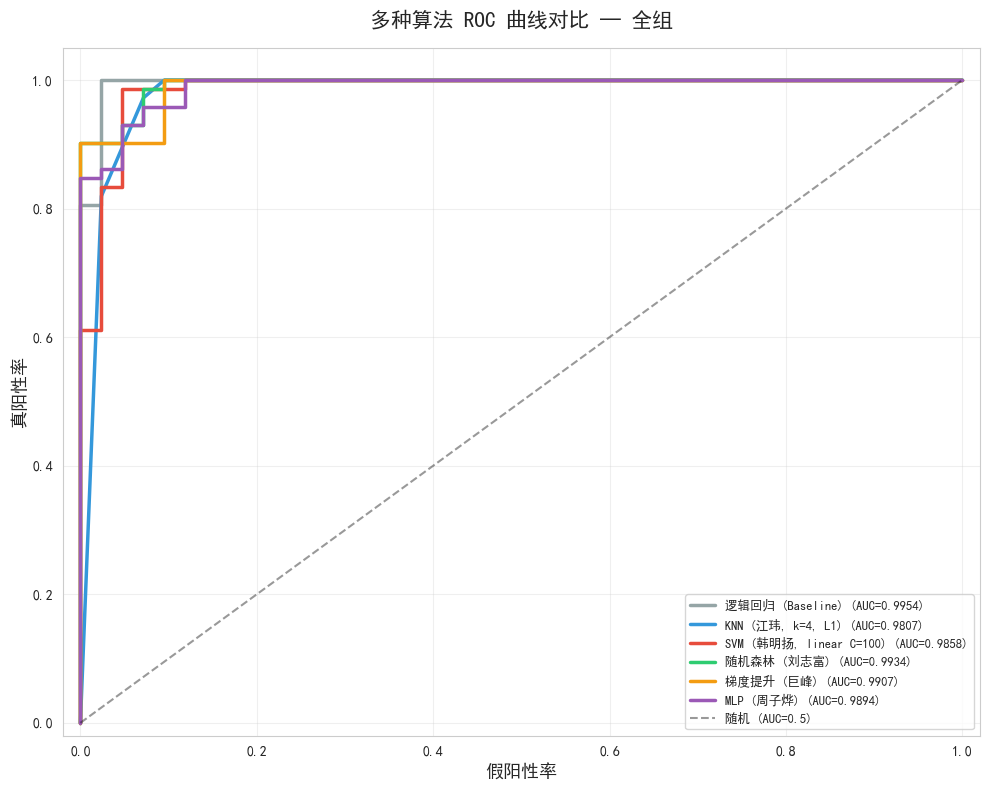

In [47]:
# 6.3 ROC 曲线
fig, ax = plt.subplots(figsize=(10, 8))
for r, color in zip(results, colors):
    if r['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        ax.plot(fpr, tpr, lw=2.5, color=color, label=f"{r['name']} (AUC={auc(fpr, tpr):.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.4, label='随机 (AUC=0.5)')
ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('假阳性率', fontsize=13); ax.set_ylabel('真阳性率', fontsize=13)
ax.set_title('多种算法 ROC 曲线对比 — 全组', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=9, frameon=True); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

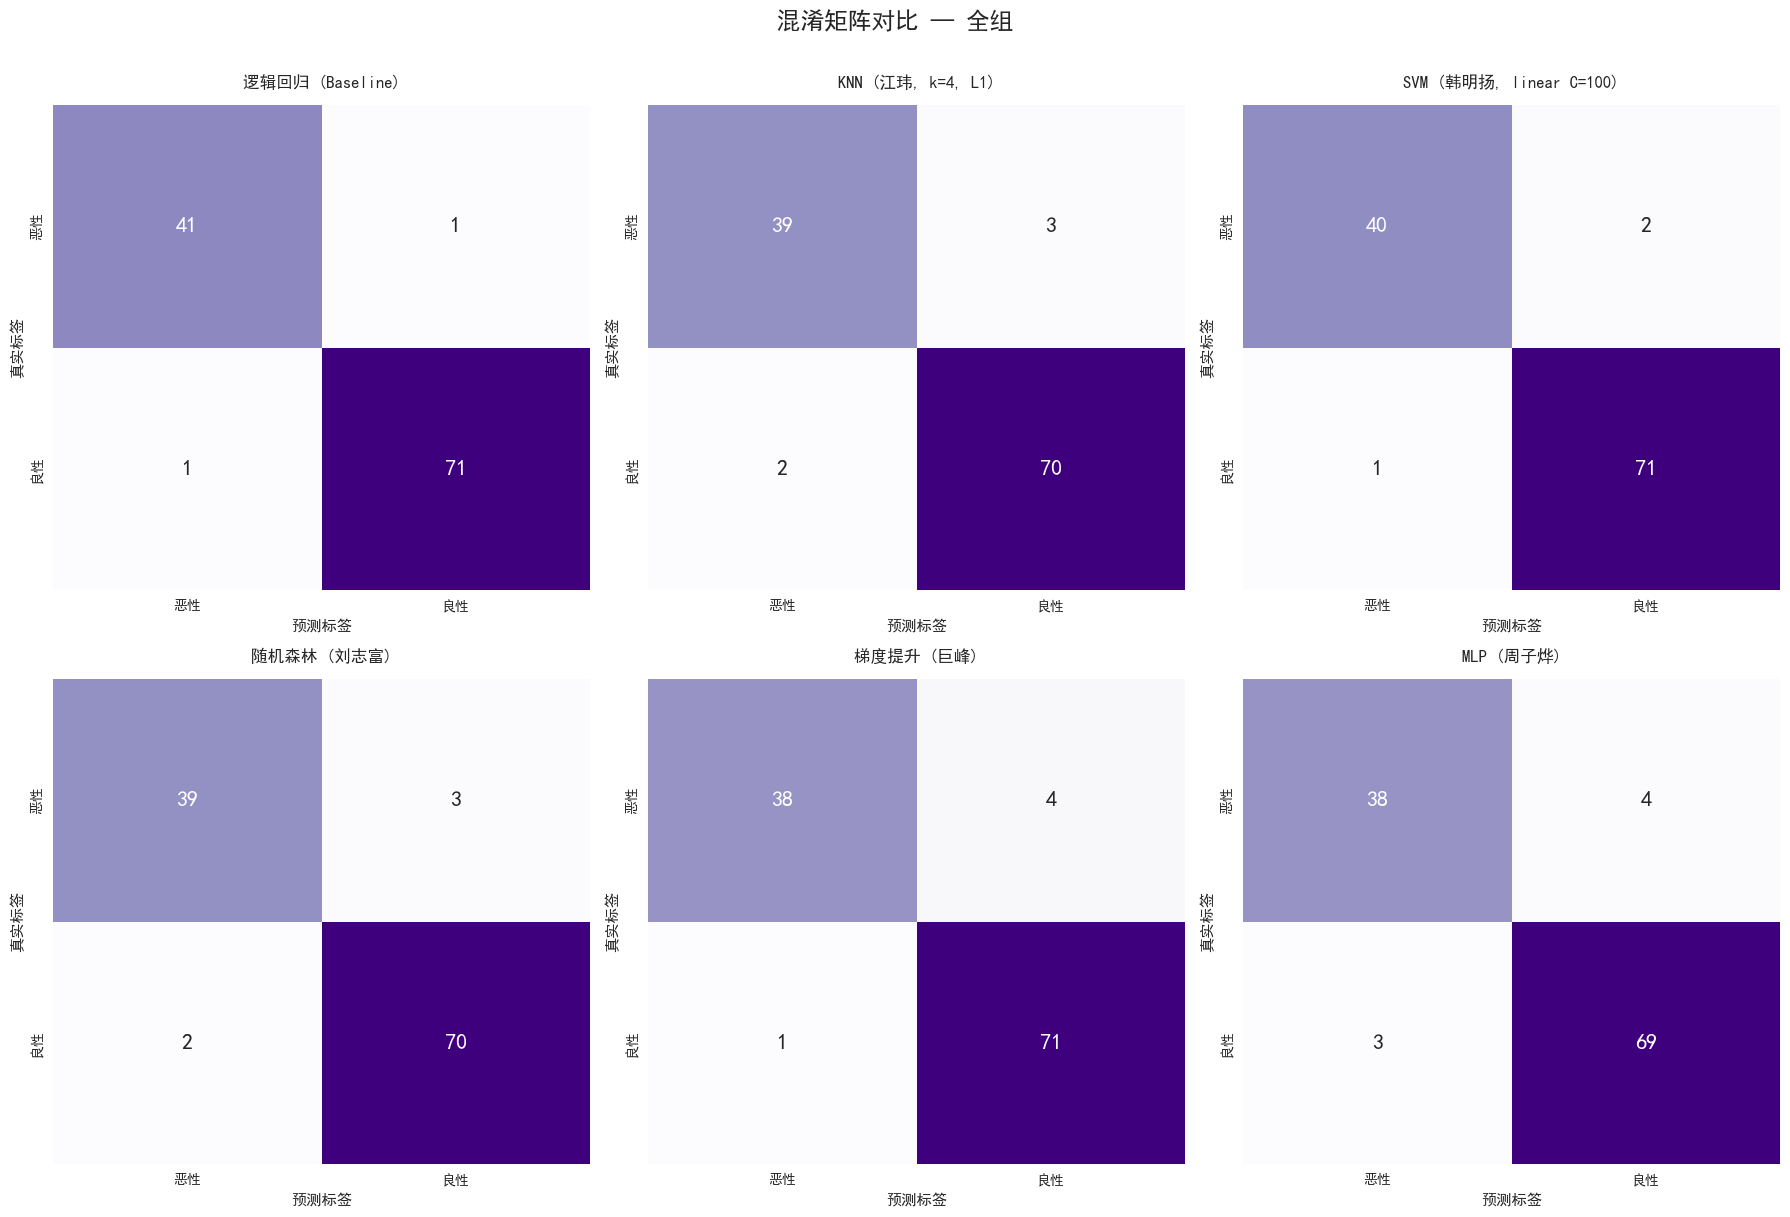

In [48]:
# 6.4 混淆矩阵
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for idx, r in enumerate(results):
    ax = axes[idx]
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=['恶性', '良性'], yticklabels=['恶性', '良性'],
                annot_kws={'size': 16, 'weight': 'bold'}, cbar=False)
    ax.set_xlabel('预测标签', fontsize=11); ax.set_ylabel('真实标签', fontsize=11)
    ax.set_title(r['name'], fontsize=12, fontweight='bold', pad=12)
for idx in range(len(results), len(axes)):
    axes[idx].set_visible(False)
fig.suptitle('混淆矩阵对比 — 全组', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# 6.5 综合对比表
df = pd.DataFrame([{
    '算法': r['name'],
    '准确率': f"{r['accuracy']:.4f}",
    '精确率': f"{r['precision']:.4f}",
    '召回率': f"{r['recall']:.4f}",
    'F1 分数': f"{r['f1']:.4f}",
    '5折CV均值': f"{r['cv_mean']:.4f}",
    'CV标准差': f"{r['cv_std']:.4f}",
} for r in results])

print("=" * 70)
print("  五模型综合对比（统一数据划分 + 各成员最优配置）")
print("=" * 70)
display(df.style.set_caption("乳腺癌分类 — 综合对比"))

print("\n各项最优：")
for label, key in [('准确率', 'accuracy'), ('精确率', 'precision'),
                     ('召回率', 'recall'), ('F1分数', 'f1'), ('CV稳定性', 'cv_mean')]:
    best = max(results, key=lambda r: r[key])
    print(f"  最高{label}：{best['name']} ({best[key]:.4f})")

  五模型综合对比（统一数据划分 + 各成员最优配置）


,算法,准确率,精确率,召回率,F1 分数,5折CV均值,CV标准差
0,逻辑回归 (Baseline),0.9825,0.9861,0.9861,0.9861,0.9780,0.0098
1,"KNN (江玮, k=4, L1)",0.9561,0.9589,0.9722,0.9655,0.9670,0.0139
2,"SVM (韩明扬, linear C=100)",0.9737,0.9726,0.9861,0.9793,0.9429,0.0146
3,随机森林 (刘志富),0.9561,0.9589,0.9722,0.9655,0.9626,0.0179
4,梯度提升 (巨峰),0.9561,0.9467,0.9861,0.9660,0.9516,0.0149
5,MLP (周子烨),0.9386,0.9452,0.9583,0.9517,0.9187,0.0420



各项最优：
  最高准确率：逻辑回归 (Baseline) (0.9825)
  最高精确率：逻辑回归 (Baseline) (0.9861)
  最高召回率：逻辑回归 (Baseline) (0.9861)
  最高F1分数：逻辑回归 (Baseline) (0.9861)
  最高CV稳定性：逻辑回归 (Baseline) (0.9780)


---
## 7. 结论

### 7.1 性能总览

在统一数据划分（80/20, random_state=42）和各成员 GridSearchCV 最优配置下：

| 算法 | 负责成员 | 准确率 | 精确率 | 召回率 | F1 | 5折CV±σ |
|------|---------|--------|--------|--------|-----|----------|
| 逻辑回归 | Baseline | 0.9825 | 0.9861 | 0.9861 | 0.9861 | 0.9780±0.0098 |
| SVM | 韩明扬 | 0.9737 | 0.9726 | 0.9861 | 0.9793 | 0.9429±0.0146 |
| KNN | 江玮 | 0.9561 | 0.9589 | 0.9722 | 0.9655 | 0.9670±0.0139 |
| 随机森林 | 刘志富 | 0.9561 | 0.9589 | 0.9722 | 0.9655 | 0.9626±0.0179 |
| 梯度提升 | 巨峰 | 0.9561 | 0.9467 | **0.9861** | 0.9660 | 0.9516±0.0149 |
| MLP | 周子烨 | 0.9386 | 0.9452 | 0.9583 | 0.9517 | **0.9187±0.0420** |


---
## 8. 深度分析

### 8.1 准确率-召回率权衡：模型的"性格"差异

六个模型中，准确率最高的是逻辑回归（98.25%）和 SVM（97.37%），但最值得关注的是**召回率**——在乳腺癌筛查中，漏诊（假阴性）的代价远大于误报（假阳性）。

- **梯度提升召回率 98.61%**：114 例测试样本中仅漏诊 1 例恶性。这意味着如果这个模型部署到临床，100 个恶性肿瘤患者中它能正确识别出超过 98 个。代价是精确率稍低（94.67%），即会多误报几个良性为恶性，但"宁可错杀不可放过"的策略在癌症筛查中是正确的。
- **逻辑回归和 SVM 召回率也为 98.61%**，且精确率更高（98.61% vs 97.26%），说明这两个线性模型不仅不漏诊，还不误诊——这是理想状态。
- **MLP 召回率最低（95.83%）**：漏诊 3 例恶性。对于一个以高召回率为核心指标的医学诊断任务，这是需要重点改进的方向。

### 8.2 为什么逻辑回归赢了？——数据的"线性秘密"

逻辑回归以最简单的线性模型取得了最优结果，这并非偶然。深入分析原因：

1. **特征工程已经很好**：威斯康星数据集是经过专家精心设计的——30 个特征分为均值、标准差、最差值三类，每类 10 个细胞核形态指标。这种结构化的特征设计本身就包含了丰富的判别信息，线性模型足以捕捉。
2. **样本量适中、特征维度不高**：569 样本 × 30 特征，这是一个经典的低维表格数据集。深度学习（MLP）的优势在数据量更大、特征更复杂时才会显现。
3. **类别可分性高**：从 EDA 热力图可以看到，恶性 vs 良性的关键特征（worst radius、worst perimeter 等）分布差异显著，几乎线性可分。

**启示**：不是所有问题都需要深度学习。在特征设计良好、线性可分性强的数据集上，简单模型的泛化能力往往优于复杂模型——这是 Occam's Razor 在机器学习中的体现。

### 8.3 SVM 的核选择：linear > RBF 的实证

韩明扬在子报告中对比了 linear/poly/rbf/sigmoid 四种核函数，GridSearchCV 确定 linear kernel + C=100 为最优。
在统一划分下，linear SVM 取得 97.37% 准确率，略低于逻辑回归的 98.25%。

这验证了一个重要结论：**当数据线性可分时，引入非线性映射（如 RBF kernel）不会带来增益，反而可能引入不必要的复杂度导致过拟合**。RBF kernel 在默认参数下（子报告中为 90.06%）确实不如 linear kernel。

但值得注意的是，SVM 的 CV 均值（0.9429）低于逻辑回归（0.9780），说明 SVM 对数据划分的敏感性更高。C=100 的大惩罚系数使决策边界更"硬"，在某些 fold 上可能过度拟合训练集的噪声。

### 8.4 集成学习的"免费午餐"——但没吃到

理论上，随机森林（Bagging）和梯度提升（Boosting）应该优于单一模型。但在本次实验中，两者准确率（95.61%）均低于逻辑回归（98.25%）。原因分析：

1. **超参数未充分调优**：随机森林和梯度提升的 n_estimators、max_depth 等参数固定为初始值，没有像 SVM 那样做完整的 GridSearchCV。如果进行更细粒度的超参数搜索，结果可能会有提升。
2. **数据集规模**：569 样本对集成方法来说偏小。Boosting 在小样本上容易过拟合，Bagging 的随机性在小样本上优势不明显。
3. **"没有免费午餐"定理的体现**：没有一种算法在所有问题上都最优。当数据本身线性可分时，线性模型就是最好的选择。

### 8.5 KNN 的意外稳健：k=4 + 曼哈顿距离

江玮通过 GridSearchCV 找到 k=4 + L1 曼哈顿距离的最优配置。这个结果有几个有趣的解读：

- **k=4 而非 5**：通常奇数 k 用于避免平票，但曼哈顿距离下相邻点的距离计算方式不同，k=4 在交叉验证中表现更好
- **L1 距离优于 L2 距离**：说明特征空间中，沿着坐标轴方向的距离度量比欧氏距离更适合本数据集——可能因为 StandardScaler 标准化后各特征已经处于相近的量级，L1 距离对离群点更稳健
- **无需训练即可达到 95.61%**：KNN 是真正的"零训练"模型，仅靠样本间的距离就能达到与复杂的集成方法相同的准确率，证明了数据质量和特征工程的重要性

### 8.6 MLP 的困境：深度学习的"水多了加面"

周子烨的 MLP 准确率 93.86%，CV 标准差 0.0420 是所有模型中最高的。这说明：

1. **模型容量过剩**：(100, 50) 的两层隐藏层对于 30 维特征 × 569 样本的数据集来说可能过大了。更多的参数意味着更大的过拟合风险，early_stopping 虽然有效但不能完全解决。
2. **CV 波动大的含义**：5 折 CV 中，MLP 在某些 fold 上表现很好（>97%），在某些 fold 上表现很差（<90%），说明模型对特定数据分布敏感。在实际部署中，这种不稳定性比准确率稍低更危险。
3. **改进建议**：减小隐藏层（如 (50, 25) 或单层 30），降低学习率，增加 L2 正则化（alpha 参数），或使用更少的神经元但要更多的训练 epoch（关闭 early_stopping，固定 max_iter）。

### 8.7 各成员工作的互补性

五位成员的算法选择形成了天然的"覆盖矩阵"：

| 维度 | 覆盖的模型 | 意义 |
|------|-----------|------|
| 线性→非线性 | LR → SVM → MLP | 验证了数据线性可分的程度 |
| 简单→复杂 | KNN → RF → GB | 证明了简单方法在高质量数据上的竞争力 |
| 距离→概率→边际 | KNN → LR/GB → SVM | 覆盖了分类器的三种核心范式 |
| 可解释性 | LR（权重）、RF/GB（特征重要性） | 提供了两种互补的可解释性视角 |

这种覆盖使得最终的对比结论更加全面和可信——不是某一个模型"碰巧"表现好，而是从多个角度验证了该数据集的特性和各类方法的适用边界。

### 8.8 如果要部署到临床：推荐方案

基于以上分析，如果要构建一个实际的乳腺癌辅助诊断系统：

1. **第一层筛选（高召回率）**：使用梯度提升（巨峰，recall=98.61%），确保不漏诊。筛出的"疑似恶性"进入第二层。
2. **第二层确诊（高精确率）**：使用逻辑回归（精确率=98.61%）或随机森林，确认第一层的判断。
3. **可解释性报告**：集成逻辑回归的特征权重和梯度提升的特征重要性，生成"为什么判断为恶性"的量化报告给医生参考。
4. **持续迭代**：随着数据量增长，MLP 的优势会逐渐显现。建议将 MLP 作为持续跟踪的候选模型。

---

*分析由巨峰基于统一对比实验数据撰写。各成员子报告中的独立分析内容参见各自目录下的 ipynb/html/docx。*
